In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../utils/week2/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 1. Data Cleaning

In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(2640, 12)
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [4]:
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)
print("Clean shape:", df.shape)

Clean shape: (2640, 12)


## 2. Exploratory Data Analysis (EDA)

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].skew())

Year                    0.000000
Month                   0.000000
Estimated_Deliveries    0.088251
Production_Units        0.129839
Avg_Price_USD          -0.000007
Battery_Capacity_kWh    0.340118
Range_km                0.341950
CO2_Saved_tons          0.659800
Charging_Stations       0.021930
dtype: float64


In [6]:
Q1 = df['Estimated_Deliveries'].quantile(0.25)
Q3 = df['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Estimated_Deliveries'] < lower) | (df['Estimated_Deliveries'] > upper)]
print(f"Outliers found: {len(outliers)} rows (range: {lower:.1f} to {upper:.1f})")
print(outliers[['Year', 'Month', 'Model', 'Estimated_Deliveries']].head())

Outliers found: 12 rows (range: -535.4 to 20337.6)
     Year  Month    Model  Estimated_Deliveries
117  2022     11  Model Y                 21296
206  2022     10  Model 3                 20841
281  2015      3  Model 3                 25410
725  2015      6  Model Y                 22315
729  2018      4  Model X                 21473


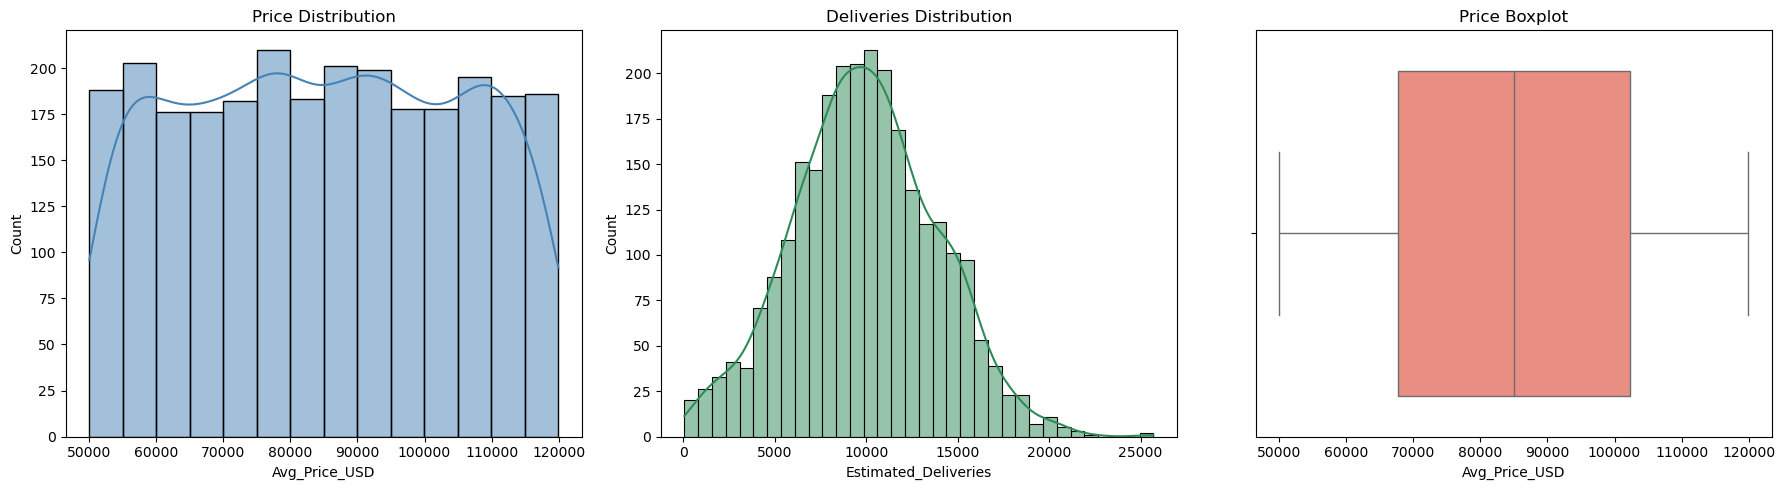

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Avg_Price_USD'], kde=True, ax=axes[0], color='steelblue').set_title('Price Distribution')
sns.histplot(df['Estimated_Deliveries'], kde=True, ax=axes[1], color='seagreen').set_title('Deliveries Distribution')
sns.boxplot(x=df['Avg_Price_USD'], ax=axes[2], color='salmon').set_title('Price Boxplot')
plt.tight_layout()
plt.show()

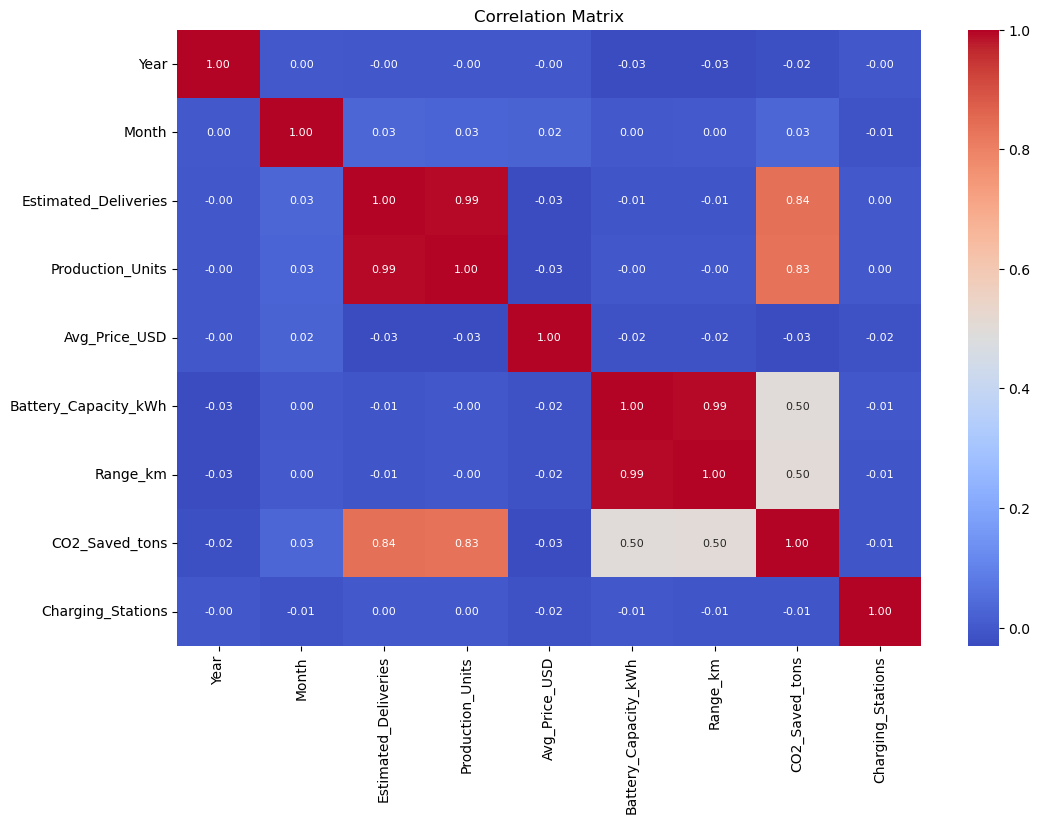

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})
plt.title("Correlation Matrix")
plt.show()

## 3. Time Series Components & Stationarity

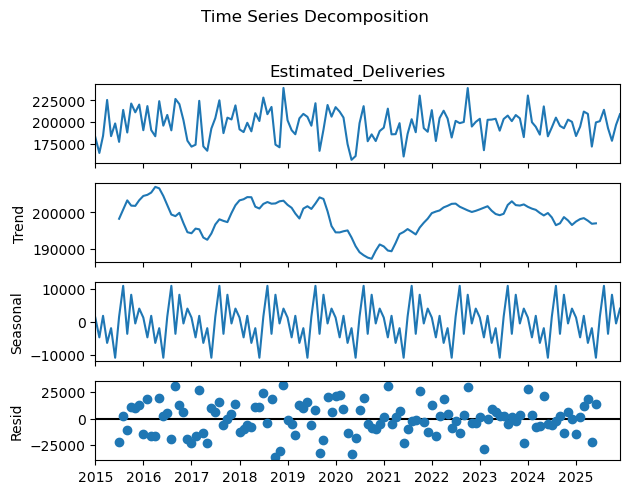

In [9]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.sort_values('Date').reset_index(drop=True)

ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS', fill_value=0)

decomposition = seasonal_decompose(ts_data, model='additive', period=12)
decomposition.plot()
plt.suptitle("Time Series Decomposition", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("Stationary    :", "Yes" if result[1] < 0.05 else "No — differencing needed")

adf_test(ts_data)

ADF Statistic : -8.8810
p-value       : 0.0000
Stationary    : Yes


## 4. Feature Engineering

In [11]:
df['Range_per_kWh'] = df['Range_km'] / df['Battery_Capacity_kWh']
df['Delivery_to_Production_Ratio'] = df['Estimated_Deliveries'] / df['Production_Units']
df = df.dropna().reset_index(drop=True)

## 5. Encoding & Chronological Split

In [12]:
df_encoded = pd.get_dummies(df, columns=['Region', 'Model'], drop_first=True)
print(df_encoded.shape)

(2640, 20)


In [13]:
X_base = df_encoded.drop(columns=['Estimated_Deliveries', 'Year', 'Month', 'Source_Type', 'Date'])
y = df_encoded['Estimated_Deliveries']

split_index = int(len(X_base) * 0.8)

X_train = X_base.iloc[:split_index].copy()
X_test  = X_base.iloc[split_index:].copy()
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

full_lag = pd.DataFrame(index=X_base.index)
full_lag['Deliveries_Lag_1']          = y.shift(1)
full_lag['Deliveries_Lag_2']          = y.shift(2)
full_lag['Deliveries_Rolling_Mean_3'] = y.shift(1).rolling(window=3).mean()

X_train = pd.concat([X_train, full_lag.iloc[:split_index]], axis=1)
X_test  = pd.concat([X_test,  full_lag.iloc[split_index:]], axis=1)

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]
X_test  = X_test.dropna()
y_test  = y_test.loc[X_test.index]

print("Train:", len(X_train), "| Test:", len(X_test))

Train: 2109 | Test: 528


## 6. Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

## 7. Regression Models & Evaluation

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=1.0)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, preds), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        "R2": round(r2_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model     MAE    RMSE      R2
0  Linear Regression  106.89  151.38  0.9983
1         Ridge (L2)  106.65  151.48  0.9983
2         Lasso (L1)  106.90  151.51  0.9983


## 8. Bias-Variance Tradeoff

The train and test R² curves track almost identically across all alpha values.
This indicates the model is not overfitting — the lag features generalize well 
because Tesla delivery data is smooth and autocorrelated.

At high alpha (>100), both curves drop together, showing underfitting (high bias)
rather than a variance problem. The optimal region is low-to-mid alpha, consistent 
with GridSearchCV selecting alpha=0.01.

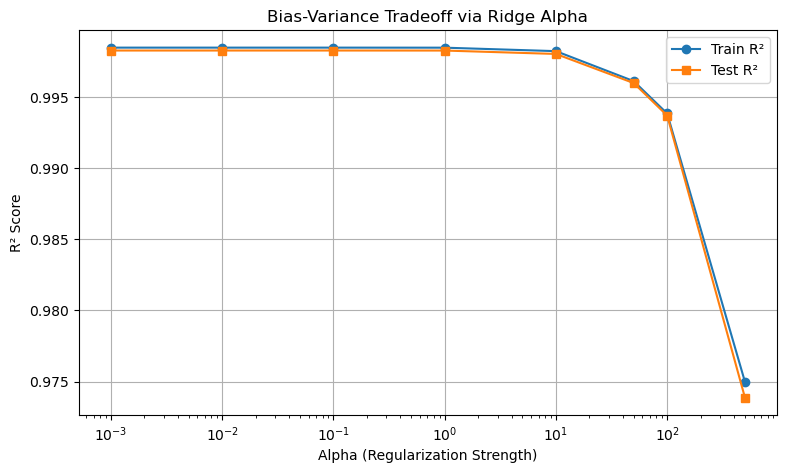

In [16]:
alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
train_r2 = []
test_r2 = []

for alpha in alphas:
    m = Ridge(alpha=alpha)
    m.fit(X_train_scaled, y_train)
    train_r2.append(r2_score(y_train, m.predict(X_train_scaled)))
    test_r2.append(r2_score(y_test, m.predict(X_test_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(alphas, train_r2, marker='o', label='Train R²')
plt.plot(alphas, test_r2, marker='s', label='Test R²')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff via Ridge Alpha')
plt.legend()
plt.grid(True)
plt.show()

## 9. Cross Validation

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=tscv, scoring='r2')
    print(f"{name} | CV R² scores: {scores.round(3)} | Mean: {scores.mean():.4f}")

Linear Regression | CV R² scores: [0.998 0.998 0.999 0.998 0.999] | Mean: 0.9985
Ridge (L2) | CV R² scores: [0.998 0.998 0.999 0.998 0.999] | Mean: 0.9984
Lasso (L1) | CV R² scores: [0.998 0.998 0.999 0.998 0.999] | Mean: 0.9985


## 10. Hyperparameter Tuning (GridSearchCV)

In [18]:
# no log transform needed — deliveries variance is already meaningful
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0]}

grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best Alpha:", grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))

Best Alpha: {'alpha': 0.01}
Best CV R²: 0.9985


## 11. sklearn Pipeline
Combines scaling and the best model into a single reusable object.

In [19]:
best_alpha = grid_search.best_params_['alpha']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=best_alpha))
])

pipeline.fit(X_train, y_train)
pipe_preds = pipeline.predict(X_test)

print("Pipeline R²  :", round(r2_score(y_test, pipe_preds), 4))
print("Pipeline RMSE:", round(np.sqrt(mean_squared_error(y_test, pipe_preds)), 2))
print("Pipeline MAE :", round(mean_absolute_error(y_test, pipe_preds), 2))

Pipeline R²  : 0.9983
Pipeline RMSE: 151.38
Pipeline MAE : 106.89


## 12. Time Series Forecasting (SARIMAX)

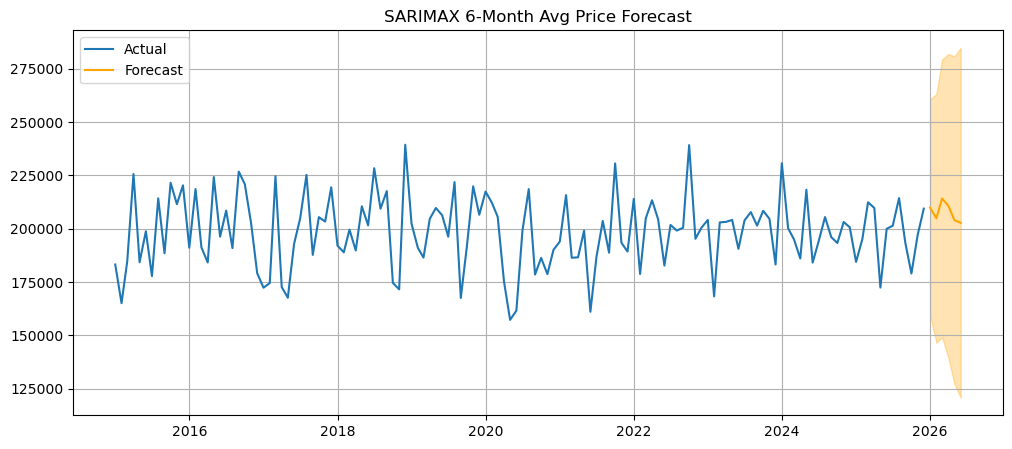

2026-01-01    209863.462916
2026-02-01    204851.343218
2026-03-01    214175.917676
2026-04-01    210741.689861
2026-05-01    203974.550844
2026-06-01    202763.872319
Freq: MS, Name: predicted_mean, dtype: float64


In [20]:
ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS').ffill()

ts_model = SARIMAX(ts_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
ts_result = ts_model.fit(disp=False)

forecast = ts_result.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(ts_data, label='Actual')
plt.plot(forecast_mean, label='Forecast', color='orange')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.3, color='orange')
plt.title("SARIMAX 6-Month Avg Price Forecast")
plt.legend()
plt.grid(True)
plt.show()

print(forecast_mean)